<a href="https://colab.research.google.com/github/XMU-Zhoubo/topic3-pycwb-gw190521/blob/main/nootbooks/01_run_pycwb_GW190521_074359.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 连接到本地运行时
```
jupyter notebook --ip=0.0.0.0 --no-browser --port=8888 --NotebookApp.allow_origin='https://colab.research.google.com'
```

# 测试

/home/zhou/miniconda3/envs/pycwb/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/zhou/miniconda3/envs/pycwb/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setupto

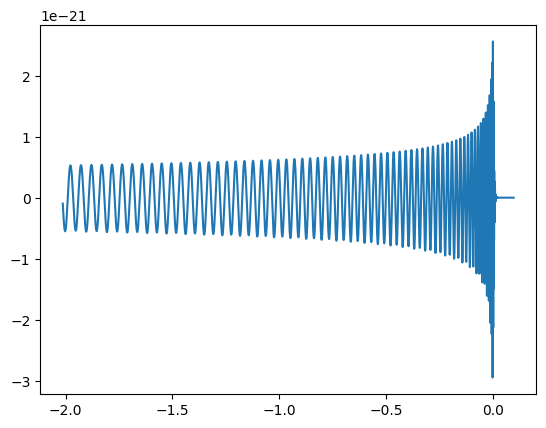

In [ ]:
from pycbc.waveform import get_td_waveform
import matplotlib.pyplot as plt

hp, hc = get_td_waveform(approximant="IMRPhenomTPHM",
                         mass1=20,
                         mass2=20,
                         spin1z=0.9,
                         spin2z=0.4,
                         inclination=1.23,
                         coa_phase=2.45,
                         distance=100,
                         delta_t=1.0/2048,
                         f_lower=20)

hp.plot()
plt.show()

(10.0, 800.0)

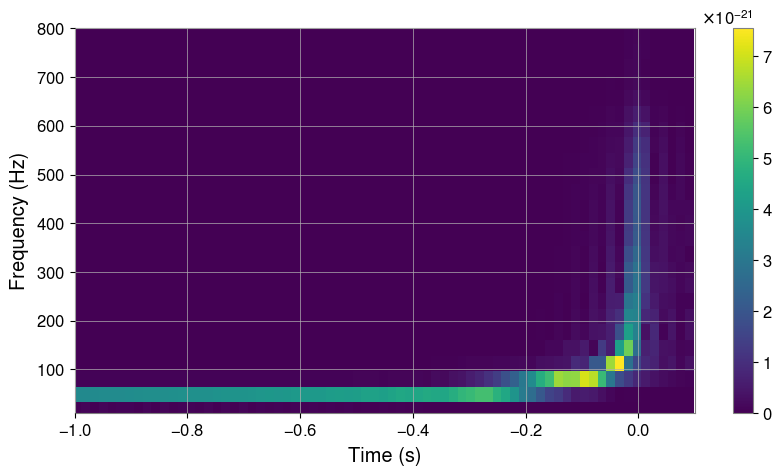

In [ ]:
from wdm_wavelet.wdm import WDM

wdm = WDM(32, 64, 6, 10)

tf_map = wdm.t2w(hp)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
tf_map.plot_energy(fig=fig, ax=ax)

ax.set_xlim(-1, 0.1)
ax.set_ylim(10, 800)

<Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>

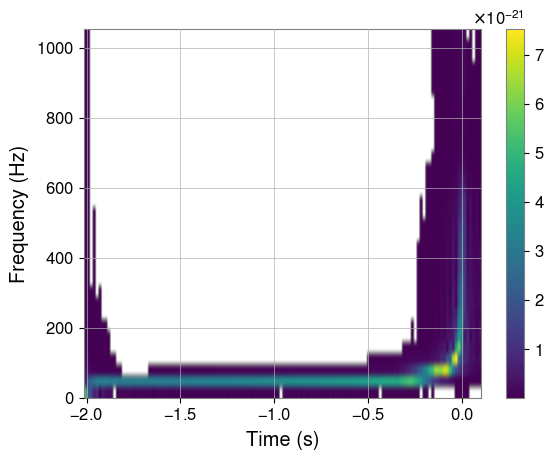

In [ ]:
 tf_map.plot_energy(low_cut=1e-24)

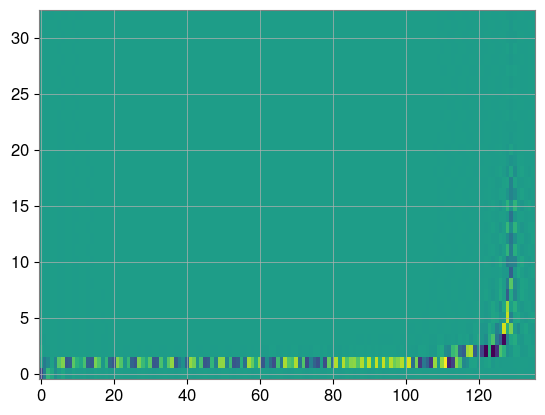

In [ ]:
fig, ax = plt.subplots()
ax.imshow(tf_map.data.real,aspect='auto', origin="lower")

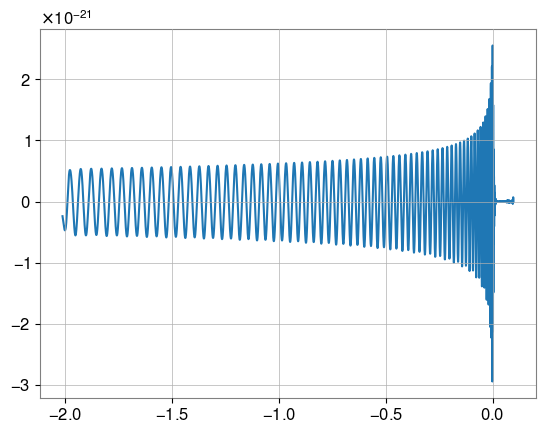

In [ ]:
 ts = wdm.w2t(tf_map)

plt.plot(ts)

(-0.1, 0.1)

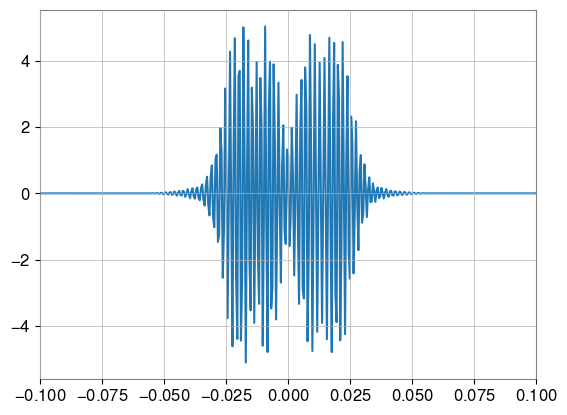

In [ ]:
from burst_waveform.models import WhiteNoiseBurst
from wdm_wavelet.wdm import WDM
params = {
    'frequency': 500,
    'bandwidth': 100,
    'duration': 0.02,
    'inj_length': 1,
    'mode': 1,
    'seed': 1234,
    'sample_rate': 2048,
}

WNB = WhiteNoiseBurst(params)
wnb_strain = WNB()

import matplotlib.pyplot as plt

plt.plot(wnb_strain)
plt.xlim(-0.1, 0.1)

<Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>

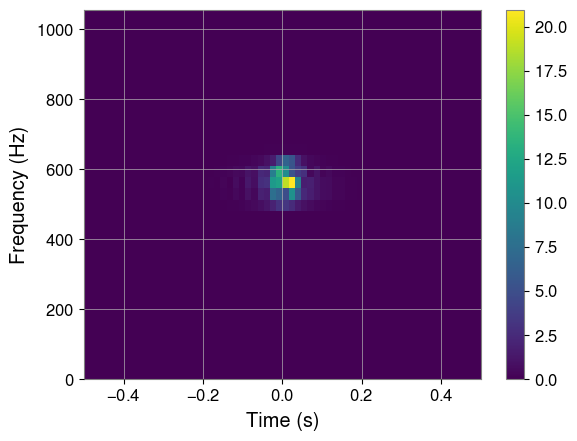

In [ ]:
wdm = WDM(32, 64, 6, 10)

tf_map = wdm.t2w(wnb_strain)

tf_map.plot_energy()

(-0.1, 0.1)

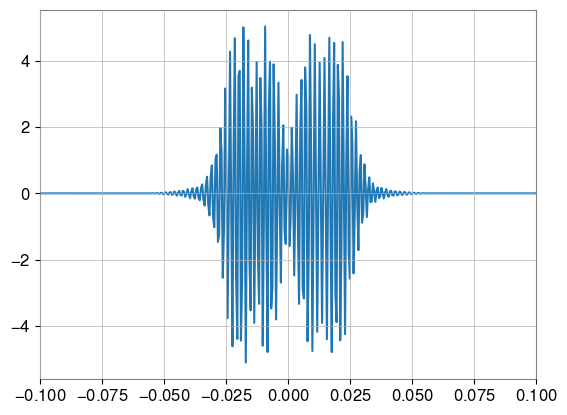

In [ ]:
 ts = wdm.w2t(tf_map)

fig, ax = plt.subplots()
ax.plot(ts)
ax.set_xlim(-0.1, 0.1)

# 样例

In [ ]:
user_parameters = """
analysis: "2G"
cfg_search: "r"

optim: False

###### network configuration ######
ifo: ["L1","H1"]
refIFO: "L1"

inRate: 16384
# lags
lagSize: 1
lagStep: 1.
lagOff: 0
lagMax: 0

# superlags
slagSize: 0 # number of super lags (simulation=1) - if slagSize=0 -> Standard Segments
slagMin: 0
slagMax: 0
slagOff: 0

# job
segLen: 1200
segMLS: 600
segTHR: 200
segEdge: 10

# frequency
fLow: 16.
fHigh: 1024.


levelR: 3
l_low: 4 # low frequency resolution level		// std (sthr = 2)
l_high: 10 # high frequency resolution level	// std (sthr = 8)

wdmXTalk: "wdmXTalk/OverlapCatalog16-1024.bin"

healpix: 7

###### cWB production thresholds & regulators ######

bpp: 0.001
subnet: 0.5
subcut: 0.0
netRHO: 5.5
# cedRHO: 5.0
netCC: 0.5
Acore: 1.7
Tgap: 0.2
Fgap: 128.0
delta: 0.5
cfg_gamma: -1.0
LOUD: 300

pattern: 5

iwindow: 30

nSky: 196608

# simulation
# simulation: None
nfactor: 1
"""

with open('user_parameters.yaml', 'w') as fp:
    fp.write(user_parameters)

In [ ]:
import os

import pycwb
from pycwb.config import Config
from pycwb.modules.logger import logger_init

if not os.environ.get('HOME_WAT_FILTERS'):
    pyburst_path = os.path.dirname(os.path.abspath(pycwb.__file__))
    os.environ['HOME_WAT_FILTERS'] = f"{os.path.abspath(pyburst_path)}/vendor"

logger_init()

config = Config('./user_parameters.yaml')

Welcome to JupyROOT 6.26/10
Loading wavelet library
Trying to load wavelet library from /home/zhou/miniconda3/envs/pycwb/lib/python3.10/site-packages/lib/wavelet.so


26-03-29 18:12:21 - logger_init - INFO - Logging initialized
26-03-29 18:12:21 - logger_init - INFO - Logging level: INFO
26-03-29 18:12:21 - logger_init - INFO - Logging file: None
26-03-29 18:12:22 - check_MRA_catalog - INFO - Checking MRA catalog
26-03-29 18:12:22 - load_MRA - INFO - Loading catalog of WDM cross-talk coefficients: /home/zhou/miniconda3/envs/pycwb/lib/python3.10/site-packages/pycwb/vendor/wdmXTalk/OverlapCatalog16-1024.bin


In [ ]:
from pycwb.modules.read_data import read_from_catalog, read_from_online
from gwpy.timeseries import TimeSeries

import requests
from gwosc.locate import get_urls
t0 = 1126259462.4

data = []
for ifo in config.ifo:
  url = get_urls(ifo, t0, t0)[-1]

  print('Downloading: ' , url)
  fn = os.path.basename(url)
  with open(fn,'wb') as strainfile:
      straindata = requests.get(url)
      strainfile.write(straindata.content)

  strain = TimeSeries.read(fn,format='hdf5.gwosc')
  d = strain.crop(t0-150, t0+150)
  d_resampled = d.resample(2048)
  data.append(d_resampled)

Downloading:  https://gwosc.org/archive/data/O1/1126170624/L-L1_LOSC_4_V1-1126256640-4096.hdf5
Downloading:  https://gwosc.org/archive/data/O1/1126170624/H-H1_LOSC_4_V1-1126256640-4096.hdf5


26-03-29 18:16:33 - data_conditioning - INFO - Start data conditioning in parallel


/home/zhou/miniconda3/envs/pycwb/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


26-03-29 18:16:36 - data_conditioning - INFO - -------------------------------------------------------
26-03-29 18:16:36 - data_conditioning - INFO - Data Conditioning Time: 2.42 seconds
26-03-29 18:16:36 - data_conditioning - INFO - -------------------------------------------------------


((<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7cdb278e0>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7cdb27700>),
 (<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7cdb279a0>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7cdb27820>))

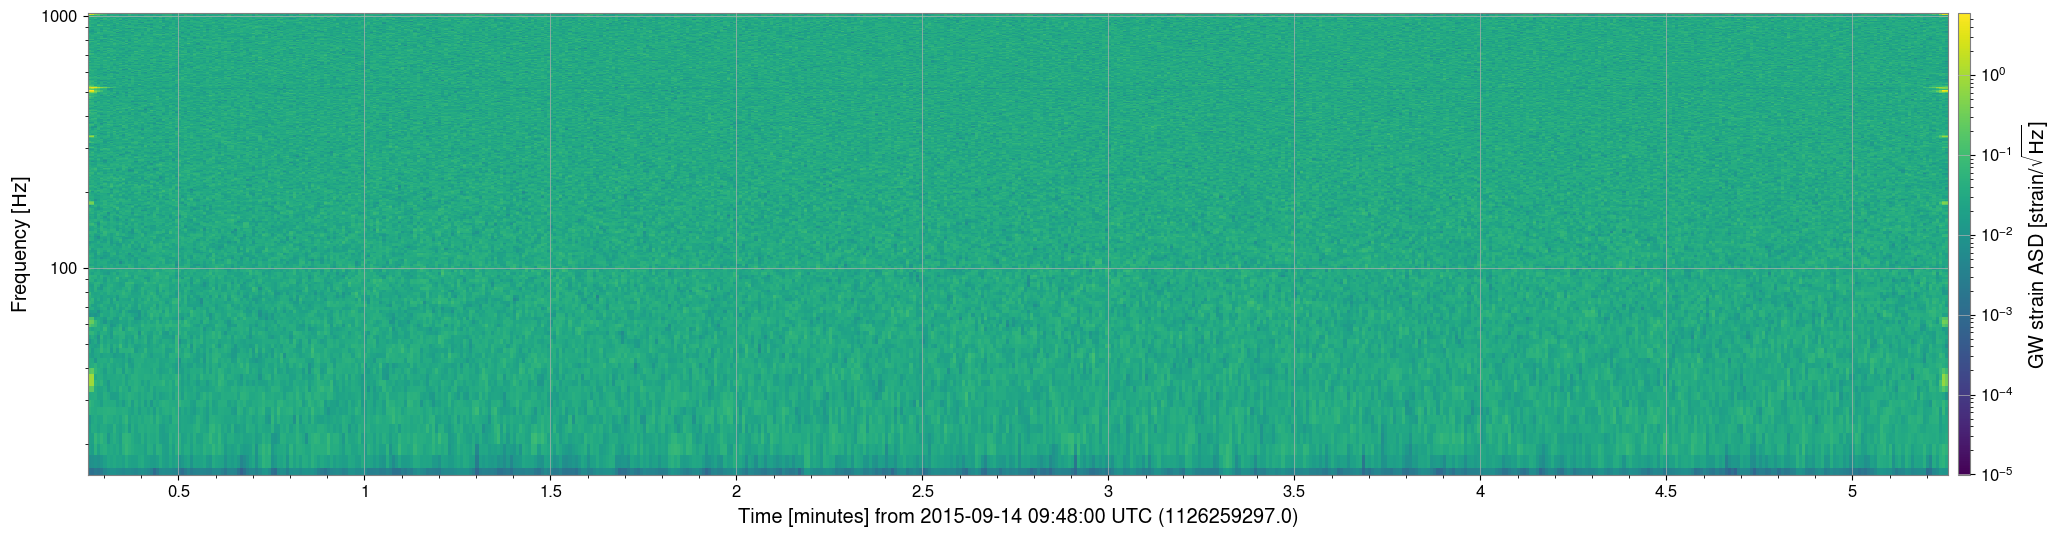

In [ ]:
from pycwb.modules.data_conditioning import data_conditioning
from pycwb.modules.plot import plot_spectrogram

strains, nRMS = data_conditioning(config, data)

# plot the spectrogram for L1
plt = plot_spectrogram(strains[0], gwpy_plot=True)
ax = plt.gca()
ax.set_ylim(15,1024)

strains, nRMS

In [ ]:
from pycwb.modules.coherence import coherence

# calculate coherence
fragment_clusters = coherence(config, strains, nRMS)

26-03-29 18:16:42 - coherence - INFO - Start coherence in parallel
26-03-29 18:16:48 - _coherence_single_res - INFO - level : 7	 rate(hz) : 16	 layers : 128	 df(hz) : 8.000000	 dt(ms) : 62.500000 
max energy in units of noise variance: 8.81448 
thresholds in units of noise variance: Eo=8.47468 Emax=16.9494 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |       10 |    165 
Coherence time for single level: 5.529178 s
26-03-29 18:16:49 - _coherence_single_res - INFO - level : 9	 rate(hz) : 4	 layers : 512	 df(hz) : 2.000000	 dt(ms) : 250.000000 
max energy in units of noise variance: 8.26642 
thresholds in units of noise variance: Eo=8.47266 Emax=16.9453 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        7 |     65 
Coherence time for single level: 5.999141 s
26-03-29 18:16:49 - _coherence_single_res - INFO - level : 10	 rate(hz) : 2	 layers : 1024	 df(hz) : 1.000000	 dt(ms) : 500.000000 
max energy in units of noise variance: 7.99343 
thresholds in units of no

In [ ]:
from pycwb.modules.super_cluster import supercluster
from pycwb.types.network import Network

network = Network(config, strains, nRMS)

pwc_list = supercluster(config, network, fragment_clusters, strains)

26-03-29 18:16:53 - set_time_shift - INFO - lag step: 1.0
26-03-29 18:16:53 - set_time_shift - INFO - number of time lags: 1
26-03-29 18:16:54 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 18:16:54 - sparse_table_from_fragment_clusters - INFO - Sparse series time: 0.84 s
26-03-29 18:16:54 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 18:16:55 - supercluster - INFO - -> Processing lag=0 ...
26-03-29 18:16:55 - supercluster - INFO -    --------------------------------------------------
26-03-29 18:16:55 - supercluster - INFO -     coher clusters|pixels      :     74|961
26-03-29 18:16:55 - supercluster - INFO -     super clusters|pixels      :      6|440
26-03-29 18:16:55 - supercluster - INFO -    defrag clusters|pixels      :      6|440
26-03-29 18:16:55 - supercluster - INFO -    subnet clusters|pixels      :      2|350
26-03-29 18:16:55 - supercluster - INFO - Supercluster done
26-03

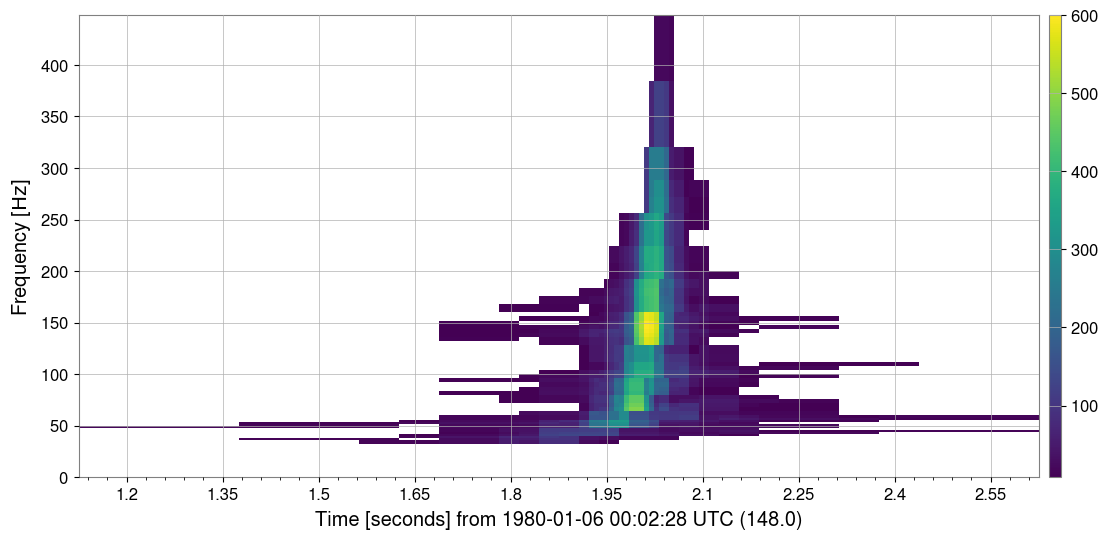

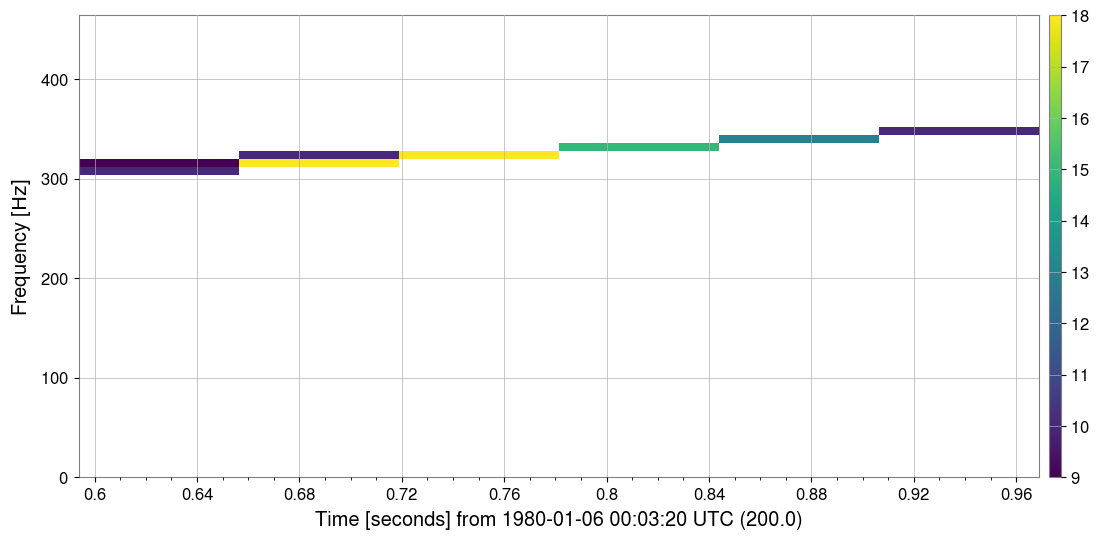

In [ ]:
# 移除 %matplotlib inline
from gwpy.spectrogram import Spectrogram
import matplotlib.pyplot as plt  # 显式导入 pyplot

for cluster in pwc_list[0].clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    # 用 fig 接收绘图对象，避免覆盖 plt
    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    fig.colorbar()  # 用 fig 调用 colorbar

plt.show()  # 本地环境显示图像的关键命令

In [ ]:
from pycwb.modules.likelihood import likelihood

events, clusters, skymap_statistics = likelihood(config, network, pwc_list)

26-03-29 18:18:18 - likelihood - INFO - -------------------------------------------------------
26-03-29 18:18:18 - likelihood - INFO - -> Processing 2 clusters in lag=0
26-03-29 18:18:18 - likelihood - INFO -    ----------------------------------------------------
26-03-29 18:18:23 - _likelihood - INFO - Selected core pixels: 1
26-03-29 18:18:23 - _likelihood - INFO -    cluster-id|pixels:     1|326
26-03-29 18:18:23 - _likelihood - INFO - 	 -> SELECTED !!!
26-03-29 18:18:24 - _likelihood - INFO - Selected core pixels: 0
26-03-29 18:18:24 - _likelihood - INFO -    cluster-id|pixels:     2|24
26-03-29 18:18:24 - _likelihood - INFO - 	 <- rejected    
26-03-29 18:18:24 - likelihood - INFO - -------------------------------------------------------
26-03-29 18:18:24 - likelihood - INFO - Total events: 1
26-03-29 18:18:24 - likelihood - INFO - Total time: 6.18 s
26-03-29 18:18:24 - likelihood - INFO - -------------------------------------------------------
mchirp_2g : 1 1 3.70e+01 2.077 150

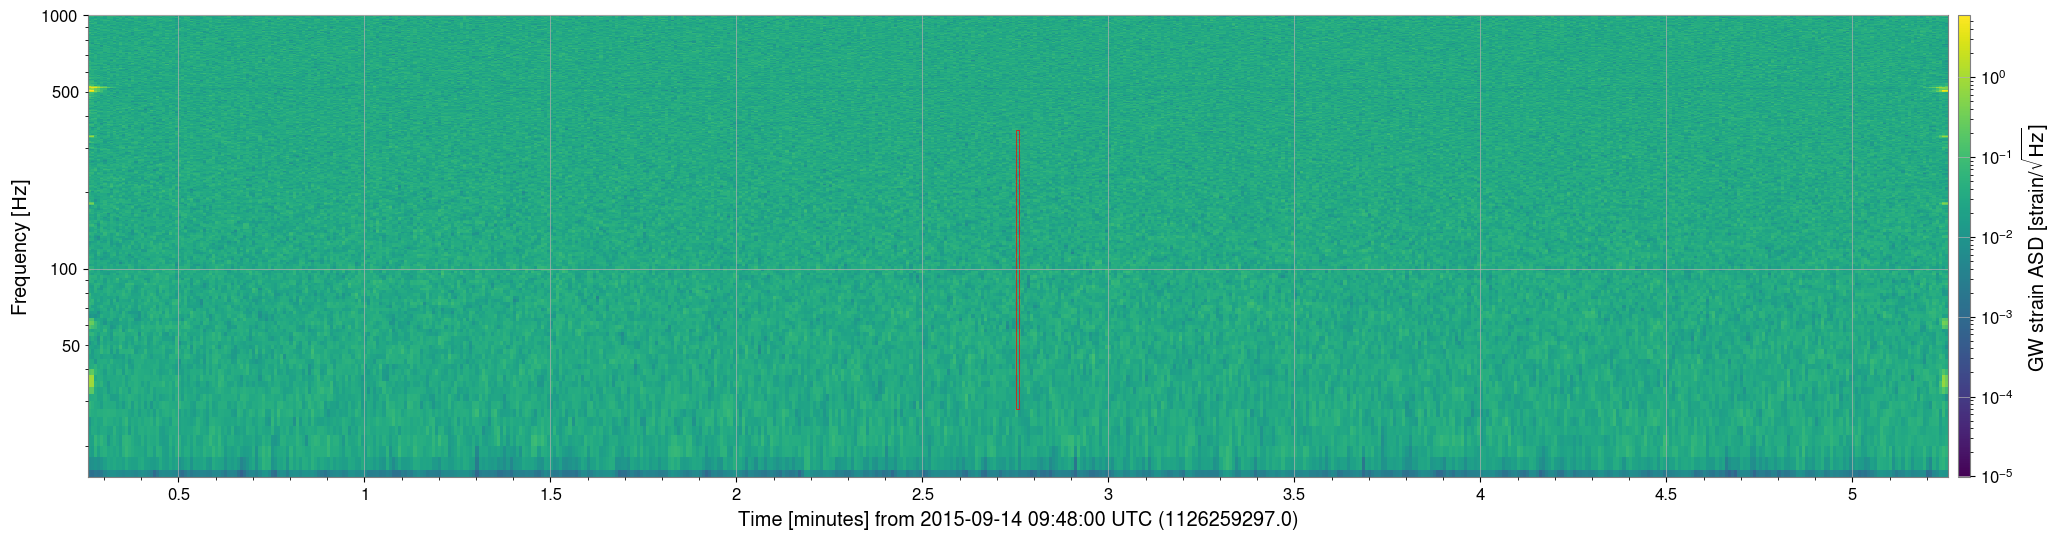

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】显式导入 pyplot
from pycwb.modules.plot import plot_event_on_spectrogram

fig = plot_event_on_spectrogram(strains[0], events)  # 【修改】用 fig 替代 plt 接收返回值
plt.show()  # 【新增】本地环境显示图像

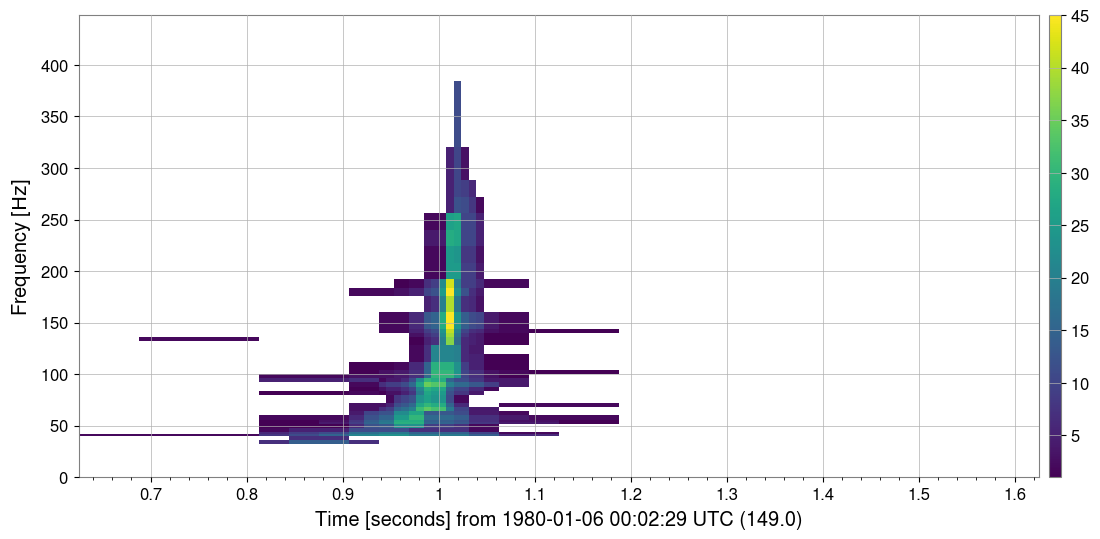

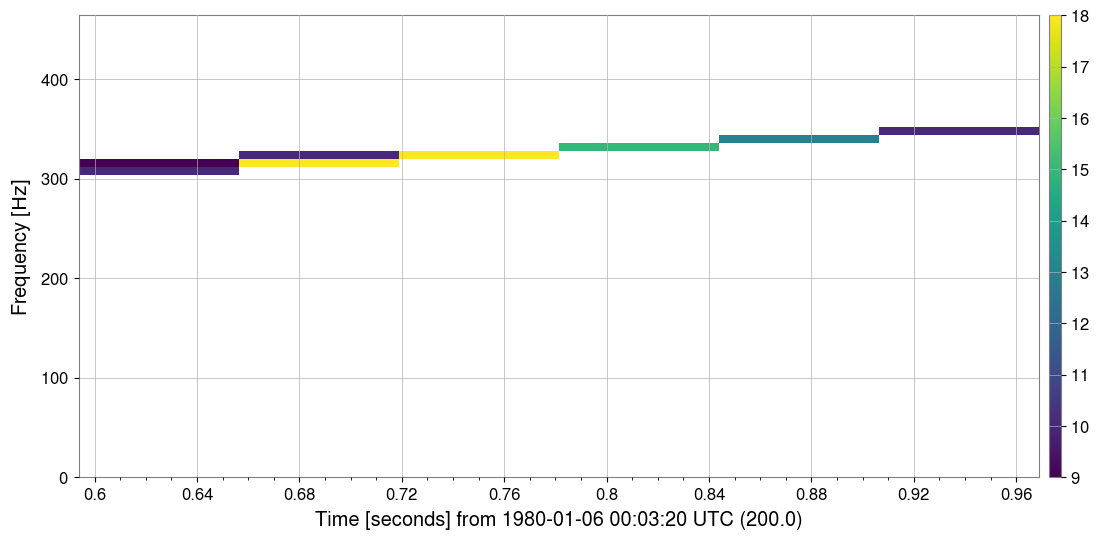

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


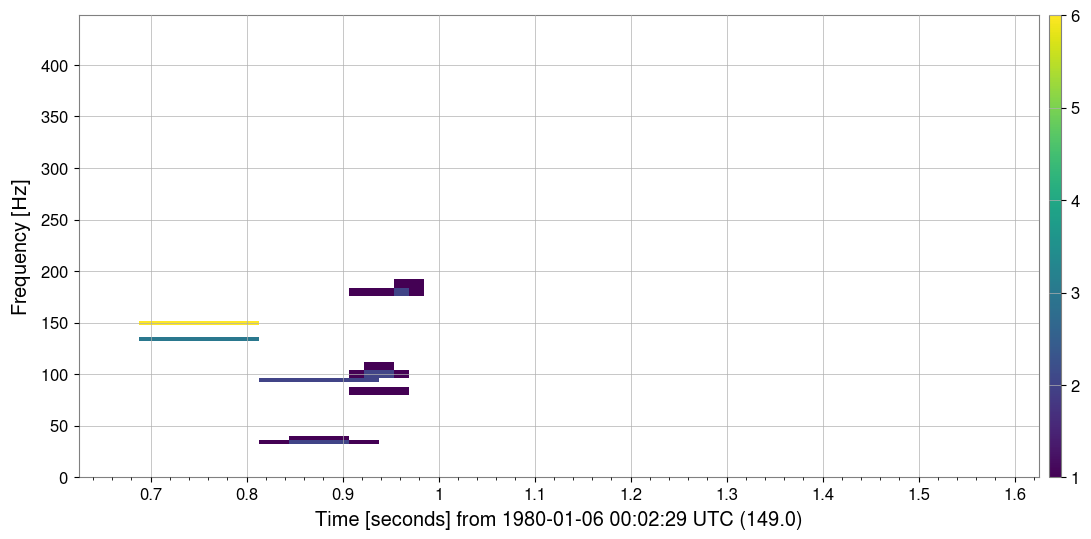

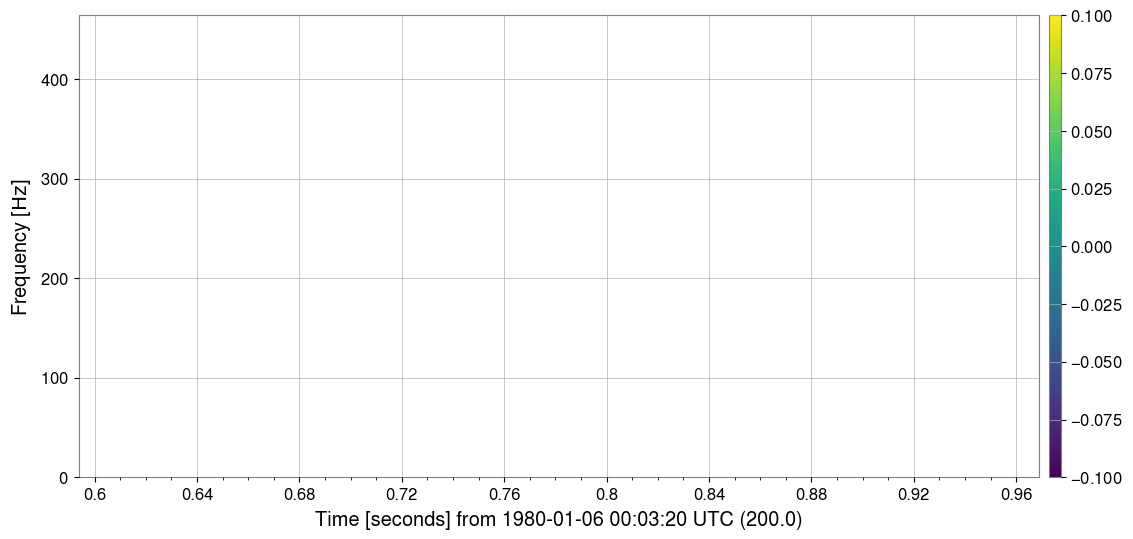

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("null")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


(149.75, 150.25)

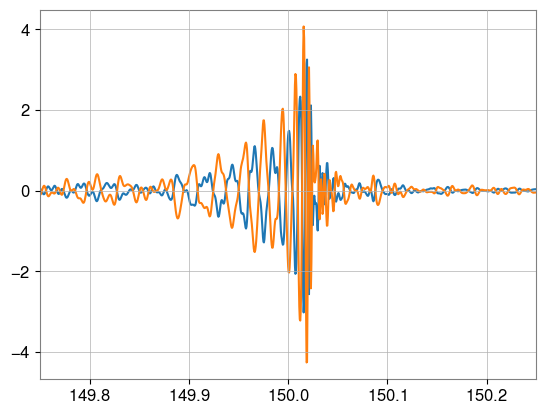

In [ ]:
from pycwb.modules.reconstruction import get_network_MRA_wave
from pycwb.modules.plot.waveform import plot_reconstructed_waveforms
from matplotlib import pyplot as plt

event = events[0]
cluster = clusters[0]
reconstructed_waves = get_network_MRA_wave(config, cluster, config.rateANA, config.nIFO, config.TDRate,
                                               'signal', 0, True)
for reconstructed_wave in reconstructed_waves:
  plt.plot(reconstructed_wave.sample_times, reconstructed_wave.data)
plt.xlim((event.left[0], event.left[0] + event.stop[0] - event.start[0]))

In [ ]:
events

[Event(nevent=1, ndim=2, run=0, rho=[16.82819938659668, np.float64(16.205471887395742), 0], netcc=[0, 0, 0], neted=[0, 0, 0, 0, 0], gnet=0.5499611496925354, anet=0.14632120728492737, inet=0.0, ecor=566.3796997070312, norm=6.39865255355835, ECOR=0.0, penalty=0, likelihood=641.0653076171875, factor=0.0, range=[0], chirp=[0, 36.999935150146484, 2.0773468017578125, 0.9884099960327148, 0.8796992301940918, 0.9492351412773132], eBBH=[], usize=0.0, ifo_list=[], eventID=[1, 0], type=[1], name=[], log=[], rate=[0, 0], volume=[326, 133], size=[135, 135], gap=[0, 0], lag=[0.0, 0.0, 0.0, 0.0], slag=[0, 0, 0], strain=[np.float64(6.75931788498177e-45)], phi=[353.8636363636364, 0, 134.62930895085447, 291.796875], theta=[155.69633519657742, 0, -65.69633519657742, 156.44354248046875], psi=[0.0], iota=[0.0], bp=[-0.5329943957257304, 0.7909650695827076], bx=[-0.22364054977265513, 0.11136299470683837], time=[1126259462.3962097, 1126259462.4034858], gps=[1126259312.3999023, 1126259312.3999023], right=[149.7

# 题目（三）第（1）问
## 修改
```
t0 = 1242459857.4
```

In [ ]:
from pycwb.modules.read_data import read_from_catalog, read_from_online
from gwpy.timeseries import TimeSeries

import requests
from gwosc.locate import get_urls
t0 = 1242459857.4

data = []
for ifo in config.ifo:
  url = get_urls(ifo, t0, t0)[-1]

  print('Downloading: ' , url)
  fn = os.path.basename(url)
  with open(fn,'wb') as strainfile:
      straindata = requests.get(url)
      strainfile.write(straindata.content)

  strain = TimeSeries.read(fn,format='hdf5.gwosc')
  d = strain.crop(t0-150, t0+150)
  d_resampled = d.resample(2048)
  data.append(d_resampled)

Downloading:  https://gwosc.org/eventapi/json/GWTC-2.1-confident/GW190521_074359/v2/L-L1_GWOSC_4KHZ_R1-1242457810-4096.hdf5
Downloading:  https://gwosc.org/eventapi/json/GWTC-2.1-confident/GW190521_074359/v2/H-H1_GWOSC_4KHZ_R1-1242457810-4096.hdf5


### 经过 PycWB data_conditioning 后的时频图

26-03-29 18:36:22 - data_conditioning - INFO - Start data conditioning in parallel


/home/zhou/miniconda3/envs/pycwb/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


26-03-29 18:36:26 - data_conditioning - INFO - -------------------------------------------------------
26-03-29 18:36:26 - data_conditioning - INFO - Data Conditioning Time: 3.70 seconds
26-03-29 18:36:26 - data_conditioning - INFO - -------------------------------------------------------


((<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7c99f6aa0>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7c99f6680>),
 (<pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7c99f6da0>,
  <pycwb.types.time_frequency_series.TimeFrequencySeries at 0x7bd7c99f6c20>))

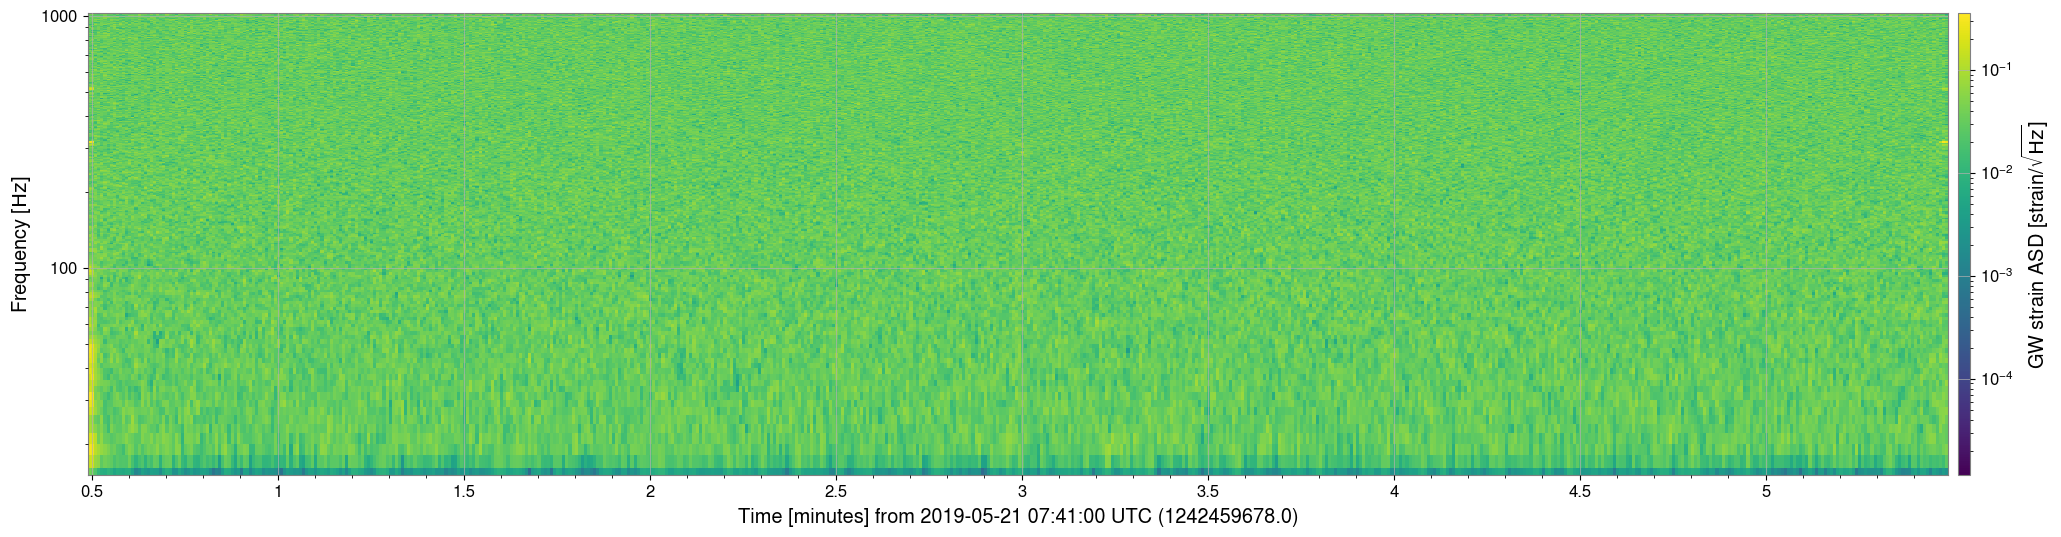

In [ ]:
from pycwb.modules.data_conditioning import data_conditioning
from pycwb.modules.plot import plot_spectrogram

strains, nRMS = data_conditioning(config, data)

# plot the spectrogram for L1
plt = plot_spectrogram(strains[0], gwpy_plot=True)
ax = plt.gca()
ax.set_ylim(15,1024)

strains, nRMS

In [ ]:
from pycwb.modules.coherence import coherence

# calculate coherence
fragment_clusters = coherence(config, strains, nRMS)

26-03-29 18:36:33 - coherence - INFO - Start coherence in parallel
26-03-29 18:36:39 - _coherence_single_res - INFO - level : 8	 rate(hz) : 8	 layers : 256	 df(hz) : 4.000000	 dt(ms) : 125.000000 
max energy in units of noise variance: 8.62635 
thresholds in units of noise variance: Eo=8.49005 Emax=16.9801 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        5 |    153 
Coherence time for single level: 5.395308 s
26-03-29 18:36:40 - _coherence_single_res - INFO - level : 10	 rate(hz) : 2	 layers : 1024	 df(hz) : 1.000000	 dt(ms) : 500.000000 
max energy in units of noise variance: 7.95643 
thresholds in units of noise variance: Eo=8.37239 Emax=16.7448 
live time in zero lag: 280 
lag | clusters | pixels 
  0 |        7 |     54 
Coherence time for single level: 6.346096 s
26-03-29 18:36:40 - _coherence_single_res - INFO - level : 9	 rate(hz) : 4	 layers : 512	 df(hz) : 2.000000	 dt(ms) : 250.000000 
max energy in units of noise variance: 8.30387 
thresholds in units of no

In [ ]:
from pycwb.modules.super_cluster import supercluster
from pycwb.types.network import Network

network = Network(config, strains, nRMS)

pwc_list = supercluster(config, network, fragment_clusters, strains)

26-03-29 18:36:44 - set_time_shift - INFO - lag step: 1.0
26-03-29 18:36:44 - set_time_shift - INFO - number of time lags: 1
26-03-29 18:36:45 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 18:36:45 - sparse_table_from_fragment_clusters - INFO - Sparse series time: 0.92 s
26-03-29 18:36:45 - sparse_table_from_fragment_clusters - INFO - ----------------------------------------
26-03-29 18:36:46 - supercluster - INFO - -> Processing lag=0 ...
26-03-29 18:36:46 - supercluster - INFO -    --------------------------------------------------
26-03-29 18:36:46 - supercluster - INFO -     coher clusters|pixels      :     67|982
26-03-29 18:36:46 - supercluster - INFO -     super clusters|pixels      :      7|519
26-03-29 18:36:46 - supercluster - INFO -    defrag clusters|pixels      :      7|519
26-03-29 18:36:46 - supercluster - INFO -    subnet clusters|pixels      :      1|370
26-03-29 18:36:46 - supercluster - INFO - Supercluster done
26-03

### PycWB 找到的 cluster 的时频稀疏图

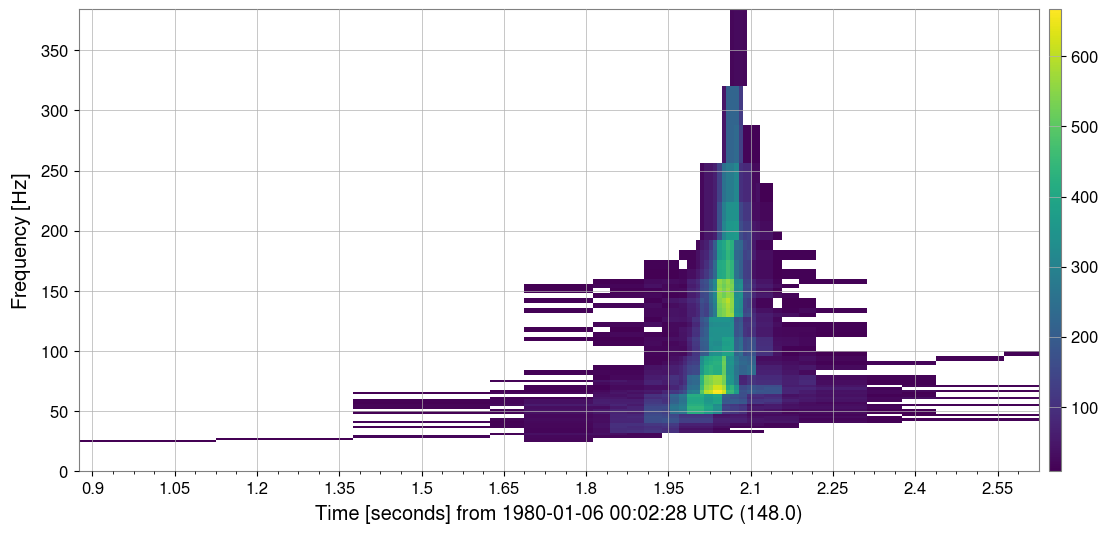

In [ ]:
# 移除 %matplotlib inline
from gwpy.spectrogram import Spectrogram
import matplotlib.pyplot as plt  # 显式导入 pyplot

for cluster in pwc_list[0].clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    # 用 fig 接收绘图对象，避免覆盖 plt
    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()
    fig.colorbar()  # 用 fig 调用 colorbar

plt.show()  # 本地环境显示图像的关键命令

In [ ]:
from pycwb.modules.likelihood import likelihood

events, clusters, skymap_statistics = likelihood(config, network, pwc_list)

26-03-29 18:36:50 - likelihood - INFO - -------------------------------------------------------
26-03-29 18:36:50 - likelihood - INFO - -> Processing 1 clusters in lag=0
26-03-29 18:36:50 - likelihood - INFO -    ----------------------------------------------------
26-03-29 18:36:55 - _likelihood - INFO - Selected core pixels: 1
26-03-29 18:36:55 - _likelihood - INFO -    cluster-id|pixels:     1|370
26-03-29 18:36:55 - _likelihood - INFO - 	 -> SELECTED !!!
26-03-29 18:36:56 - likelihood - INFO - -------------------------------------------------------
26-03-29 18:36:56 - likelihood - INFO - Total events: 1
26-03-29 18:36:56 - likelihood - INFO - Total time: 5.80 s
26-03-29 18:36:56 - likelihood - INFO - -------------------------------------------------------
mchirp_2g : 1 1 4.40e+01 2.991 150.061 0.000 1.038 



### 把 event 标到时频图上

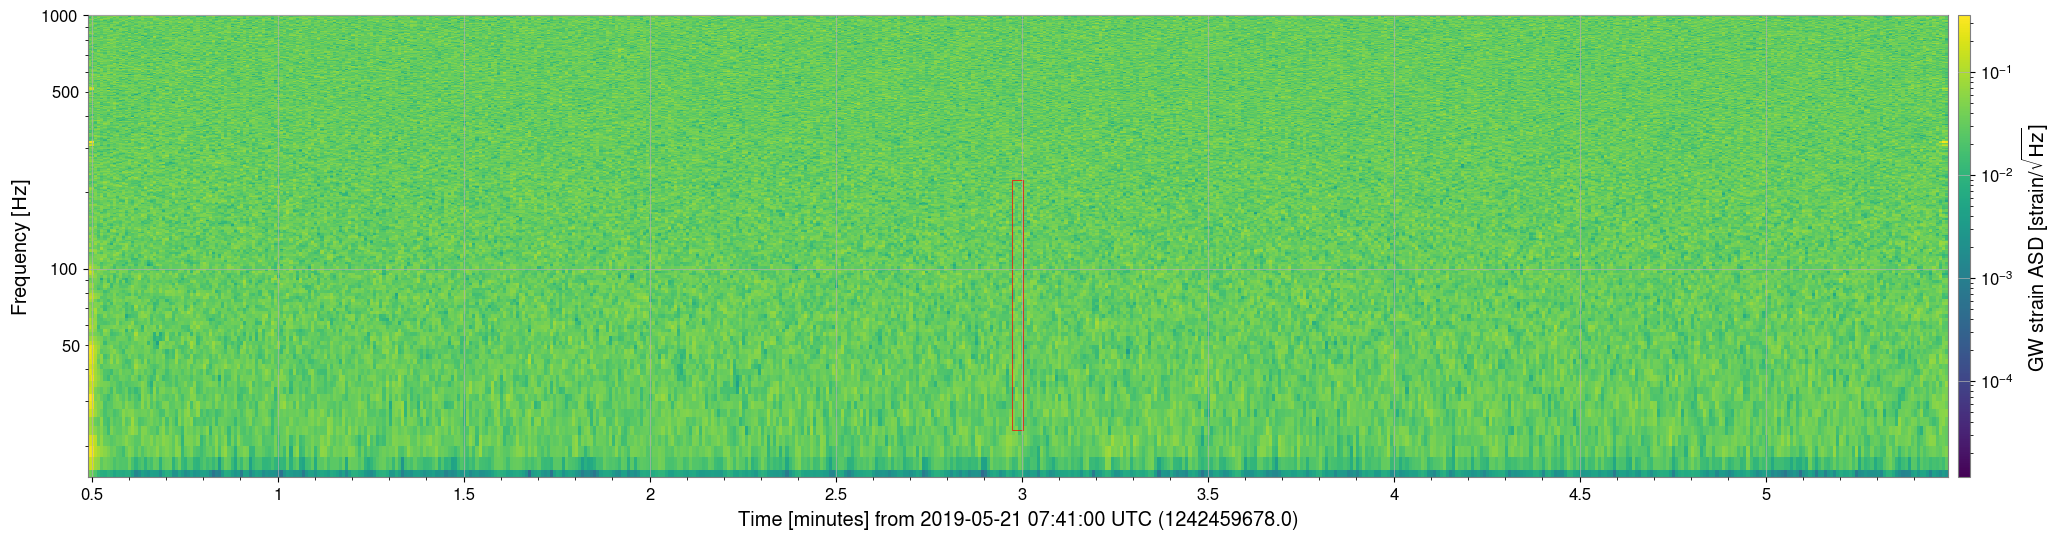

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】显式导入 pyplot
from pycwb.modules.plot import plot_event_on_spectrogram

fig = plot_event_on_spectrogram(strains[0], events)  # 【修改】用 fig 替代 plt 接收返回值
plt.show()  # 【新增】本地环境显示图像

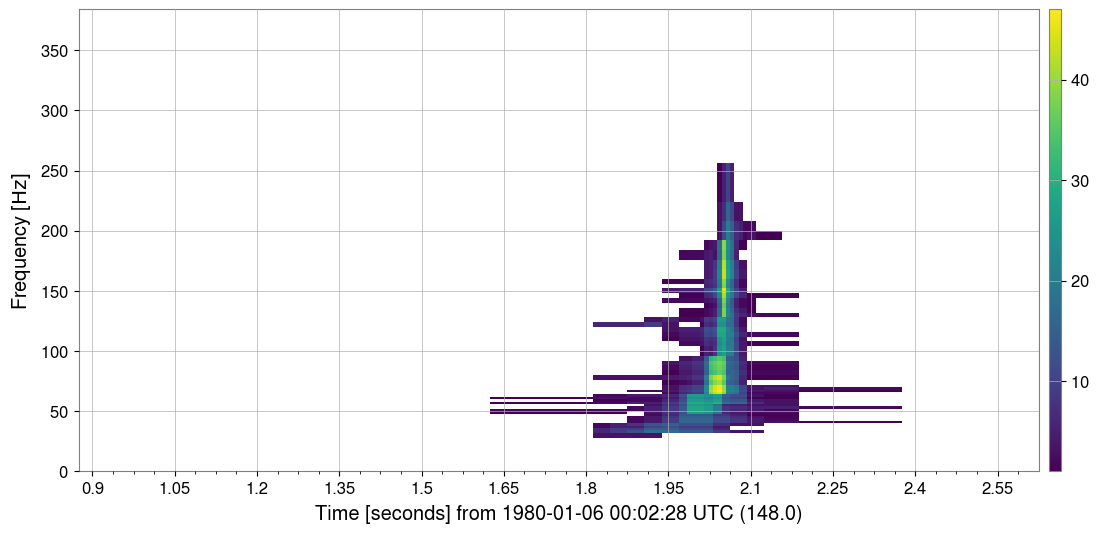

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("likelihood")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


### 另一类 cluster map，能当对照图用

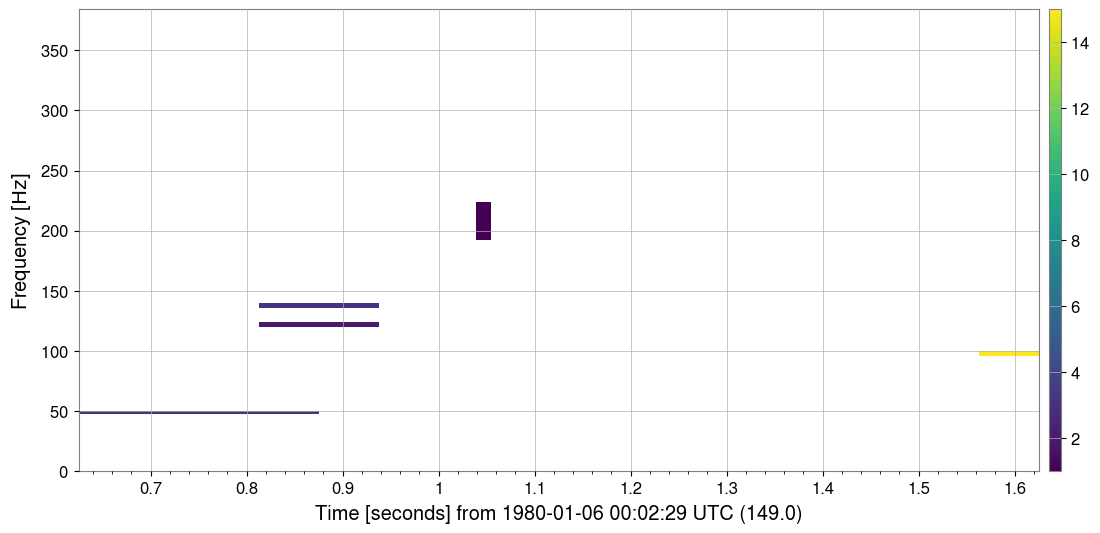

In [ ]:
# 移除 %matplotlib inline
import matplotlib.pyplot as plt  # 【新增】
from gwpy.spectrogram import Spectrogram

for cluster in clusters:
    merged_map, start, dt, df = cluster.get_sparse_map("null")

    fig = Spectrogram(merged_map, t0=start, dt=dt, f0=0, df=df).plot()  # 【修改】plt→fig
    fig.colorbar()  # 【修改】plt→fig

plt.show()  # 【新增】


### PycWB 重构的时域波形

(149.0, 150.75)

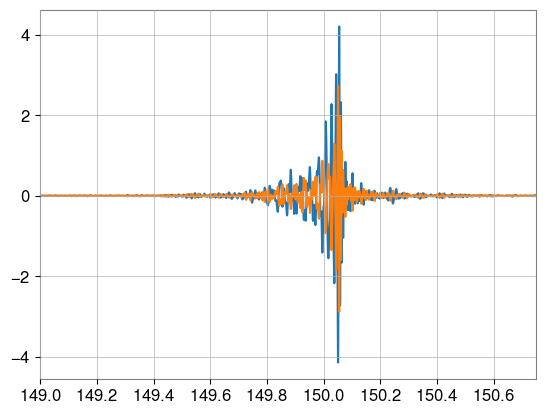

In [ ]:
from pycwb.modules.reconstruction import get_network_MRA_wave
from pycwb.modules.plot.waveform import plot_reconstructed_waveforms
from matplotlib import pyplot as plt

event = events[0]
cluster = clusters[0]
reconstructed_waves = get_network_MRA_wave(config, cluster, config.rateANA, config.nIFO, config.TDRate,
                                               'signal', 0, True)
for reconstructed_wave in reconstructed_waves:
  plt.plot(reconstructed_wave.sample_times, reconstructed_wave.data)
plt.xlim((event.left[0], event.left[0] + event.stop[0] - event.start[0]))

In [ ]:
events

[Event(nevent=1, ndim=2, run=0, rho=[15.651582717895508, np.float64(14.936389996515237), 0], netcc=[0, 0, 0], neted=[0, 0, 0, 0, 0], gnet=0.5748118162155151, anet=0.12673026323318481, inet=0.0, ecor=495.2447509765625, norm=6.891351222991943, ECOR=0.0, penalty=0, likelihood=665.4969482421875, factor=0.0, range=[0], chirp=[0, 44.00021743774414, 2.991448402404785, 0.9875091910362244, 0.8859060406684875, 0.933883011341095], eBBH=[], usize=0.0, ifo_list=[], eventID=[1, 0], type=[1], name=[], log=[], rate=[0, 0], volume=[370, 149], size=[151, 150], gap=[0, 0], lag=[0.0, 0.0, 0.0, 0.0], slag=[0, 0, 0], strain=[np.float64(2.6069535980258567e-45)], phi=[279.84375, 0, 274.53102865302935, 257.6953125], theta=[75.83047778522995, 0, 14.169522214770055, 111.38194274902344], psi=[0.0], iota=[0.0], bp=[0.8409342104858897, -0.6128354419842369], bx=[-0.4339946475654604, 0.3741226278236298], time=[1242459857.4323273, 1242459857.4376523], gps=[1242459707.3999023, 1242459707.3999023], right=[149.25, 149.25